In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target_column"] = data.target

In [3]:
# Check missing values
print(df.isnull().sum())

# Drop or fill missing values
df = df.dropna()

# Convert categorical to numeric
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target_column              0
dtype: int64


In [4]:
X = df.drop("target_column", axis=1)
y = df["target_column"]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
selector = SelectKBest(score_func=chi2, k=5)
X_new = selector.fit_transform(abs(X_scaled), y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['mean area', 'radius error', 'area error', 'worst radius',
       'worst area'],
      dtype='str')


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

In [8]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [9]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7456140350877193
              precision    recall  f1-score   support

           0       0.89      0.37      0.52        43
           1       0.72      0.97      0.83        71

    accuracy                           0.75       114
   macro avg       0.80      0.67      0.68       114
weighted avg       0.78      0.75      0.71       114



In [11]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8421052631578947
              precision    recall  f1-score   support

           0       0.86      0.70      0.77        43
           1       0.84      0.93      0.88        71

    accuracy                           0.84       114
   macro avg       0.85      0.81      0.82       114
weighted avg       0.84      0.84      0.84       114



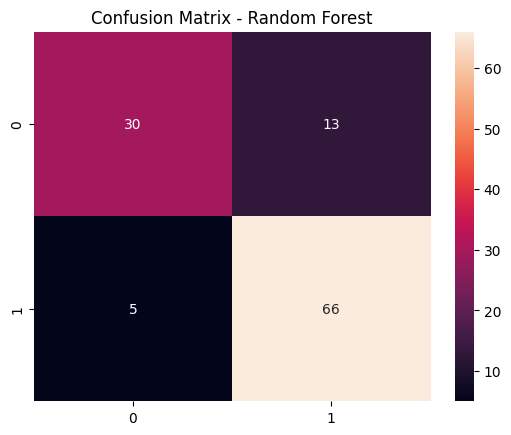

In [12]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

SyntaxError: invalid syntax (705839774.py, line 1)